In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv


In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive visualization
import plotly.express as px

# Settings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# Load dataset
df = pd.read_csv("/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv")

# Show first 5 rows
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Dataset shape
print("Dataset Shape:", df.shape)

print("\n-----------------------\n")

# Column names
print("Columns in Dataset:\n")
print(df.columns)

print("\n-----------------------\n")

# Dataset information
df.info()


Dataset Shape: (9800, 18)

-----------------------

Columns in Dataset:

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

-----------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null 

In [5]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [6]:
# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Check data types again
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [7]:
# Create time-based features
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Day'] = df['Order Date'].dt.day
df['Order Weekday'] = df['Order Date'].dt.day_name()
df['Order Quarter'] = df['Order Date'].dt.quarter

# Preview dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Day,Order Weekday,Order Quarter
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,8,Wednesday,4
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,8,Wednesday,4
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,12,Monday,2
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,11,Tuesday,4
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,11,Tuesday,4


In [8]:
# Create shipping delay feature
df['Shipping Delay'] = (df['Ship Date'] - df['Order Date']).dt.days

# Check results
df[['Order Date', 'Ship Date', 'Shipping Delay']].head()

,Order Date,Ship Date,Shipping Delay
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [12]:
# Drop Postal Code column (not useful for analytics)
df = df.drop(columns=['Postal Code'])

# Verify
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Order Year', 'Order Month', 'Order Day', 'Order Weekday',
       'Order Quarter', 'Shipping Delay'],
      dtype='object')

## Data Integrity Validation

Before performing analysis, we validate the dataset to ensure there are no logical inconsistencies.

The following checks will be performed:

1. Verify there are no negative sales values
2. Check for invalid shipping delays
3. Ensure Ship Date is always after Order Date

These validations help ensure the dataset is reliable for further analysis.

In [13]:
# Check for negative sales
negative_sales = df[df['Sales'] < 0]

print("Negative Sales Records:", len(negative_sales))

print("\n---------------------\n")

# Check negative shipping delays
negative_delay = df[df['Shipping Delay'] < 0]

print("Negative Shipping Delay Records:", len(negative_delay))

print("\n---------------------\n")

# Check if ship date is before order date
invalid_dates = df[df['Ship Date'] < df['Order Date']]

print("Invalid Date Records:", len(invalid_dates))

Negative Sales Records: 0

---------------------

Negative Shipping Delay Records: 0

---------------------

Invalid Date Records: 0


## Exploratory Data Analysis (EDA)

In this section we explore the dataset to understand overall sales behavior.

Key objectives:

- Understand total revenue generated
- Analyze sales distribution
- Identify high value orders
- Detect possible outliers in sales

This helps build an initial understanding of business performance.

In [14]:
# Basic statistics of sales
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

## Sales Distribution Analysis

Understanding the distribution of sales helps identify:

- skewness in the dataset
- presence of high value orders
- possible outliers

Retail datasets often follow a long-tail distribution where many small orders exist and few very large transactions occur.

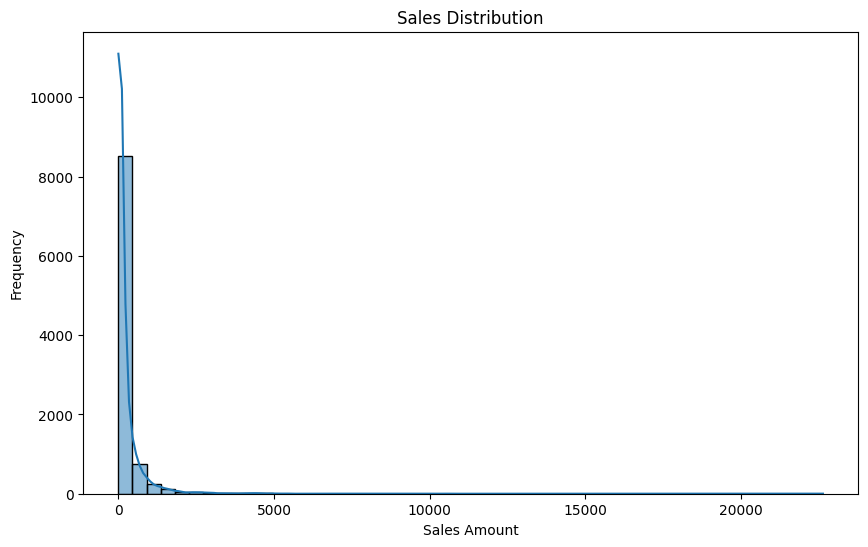

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(df['Sales'], bins=50, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")

plt.show()

## High Value Sales Analysis

Retail businesses often experience a long-tail distribution where a small number of orders contribute a large portion of total revenue.

In this section we identify high-value transactions and analyze their impact on total sales.

In [16]:
df.sort_values(by="Sales", ascending=False).head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Day,Order Weekday,Order Quarter,Shipping Delay
2697,2698,CA-2015-145317,2015-03-18,2015-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,2015,3,18,Wednesday,1,5
6826,6827,CA-2017-118689,2017-10-02,2017-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,Indiana,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,2017,10,2,Monday,4,7
8153,8154,CA-2018-140151,2018-03-23,2018-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,Washington,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,2018,3,23,Friday,1,2
2623,2624,CA-2018-127180,2018-10-22,2018-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,New York,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,2018,10,22,Monday,4,2
4190,4191,CA-2018-166709,2018-11-17,2018-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,Delaware,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,2018,11,17,Saturday,4,5
9039,9040,CA-2017-117121,2017-12-17,2017-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,Michigan,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,2017,12,17,Sunday,4,4
4098,4099,CA-2015-116904,2015-09-23,2015-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,Minnesota,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,2015,9,23,Wednesday,3,5
4277,4278,US-2017-107440,2017-04-16,2017-04-20,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,New Jersey,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,2017,4,16,Sunday,2,4
8488,8489,CA-2017-158841,2017-02-02,2017-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,Virginia,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,2017,2,2,Thursday,1,2
6425,6426,CA-2017-143714,2017-05-23,2017-05-27,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,Pennsylvania,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,2017,5,23,Tuesday,2,4


## Pareto Analysis (80/20 Rule)

The Pareto Principle suggests that a large portion of business outcomes
often come from a small portion of inputs.

In retail analytics, this typically means that a small percentage of orders
generate the majority of total revenue.

In this section we evaluate how much of the total revenue is contributed
by the top percentage of orders.

In [17]:
# Sort sales in descending order
sales_sorted = df.sort_values(by='Sales', ascending=False)

# Calculate cumulative sales
sales_sorted['Cumulative Sales'] = sales_sorted['Sales'].cumsum()

# Calculate cumulative percentage
total_sales = sales_sorted['Sales'].sum()

sales_sorted['Cumulative %'] = 100 * sales_sorted['Cumulative Sales'] / total_sales

sales_sorted[['Sales','Cumulative Sales','Cumulative %']].head(10)

,Sales,Cumulative Sales,Cumulative %
2697,22638.480,22638.480,1.001022
6826,17499.950,40138.430,1.774830
8153,13999.960,54138.390,2.393876
2623,11199.968,65338.358,2.889113
4190,10499.970,75838.328,3.353398
9039,9892.740,85731.068,3.790832
4098,9449.950,95181.018,4.208688
4277,9099.930,104280.948,4.611066
8488,8749.950,113030.898,4.997969
6425,8399.976,121430.874,5.369396


## Pareto Chart (Revenue Concentration)

The Pareto Chart helps visualize how revenue accumulates as we move from the highest-value orders to the lowest.

This helps answer key business questions:

* Do a small percentage of orders generate most of the revenue?
* Is revenue highly concentrated among a few transactions?

Understanding this helps businesses focus on high-value products and customers.


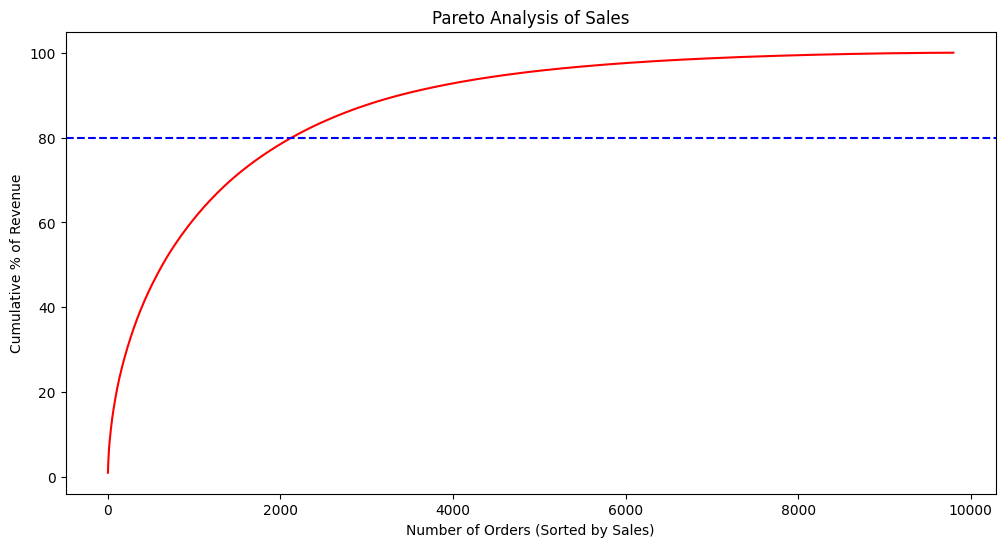

In [18]:
plt.figure(figsize=(12,6))

# Plot cumulative percentage
plt.plot(sales_sorted['Cumulative %'].values, color='red')

plt.title("Pareto Analysis of Sales")
plt.xlabel("Number of Orders (Sorted by Sales)")
plt.ylabel("Cumulative % of Revenue")

plt.axhline(80, color='blue', linestyle='--')

plt.show()

## Determining the 80% Revenue Contribution Point

Using the Pareto analysis, we now determine exactly how many orders are required
to generate 80% of the total revenue.

This helps identify how concentrated revenue is among top-performing transactions.

In [19]:
# Find the number of orders required to reach 80% revenue
orders_80 = sales_sorted[sales_sorted['Cumulative %'] <= 80].shape[0]

total_orders = df.shape[0]

percentage_orders = (orders_80 / total_orders) * 100

print("Orders contributing to 80% revenue:", orders_80)
print("Total orders:", total_orders)
print("Percentage of orders contributing to 80% revenue:", round(percentage_orders,2), "%")

Orders contributing to 80% revenue: 2130
Total orders: 9800
Percentage of orders contributing to 80% revenue: 21.73 %


## Category Level Sales Analysis

Understanding how revenue is distributed across product categories
helps identify the main revenue drivers for the business.

In this section we analyze total sales generated by each product category.

In [21]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

## Category Revenue Visualization

To better understand the contribution of each product category,
we visualize the total sales by category.

This helps identify which product segments drive the most revenue.

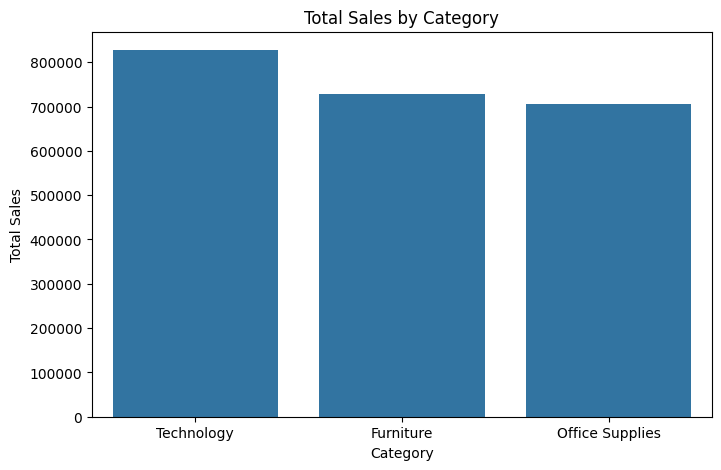

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(x=category_sales.index, y=category_sales.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

## Sub-Category Sales Analysis

While category level analysis provides a high level overview,
sub-category analysis reveals the specific product groups that drive revenue.

This helps businesses identify:

- the most profitable product types
- products that should be promoted more
- segments that contribute less to revenue

In [23]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

subcategory_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

## Top Revenue Generating Product Types

To better understand which product types contribute the most revenue,
we visualize the top performing sub-categories.

This helps identify the key product segments driving business performance.


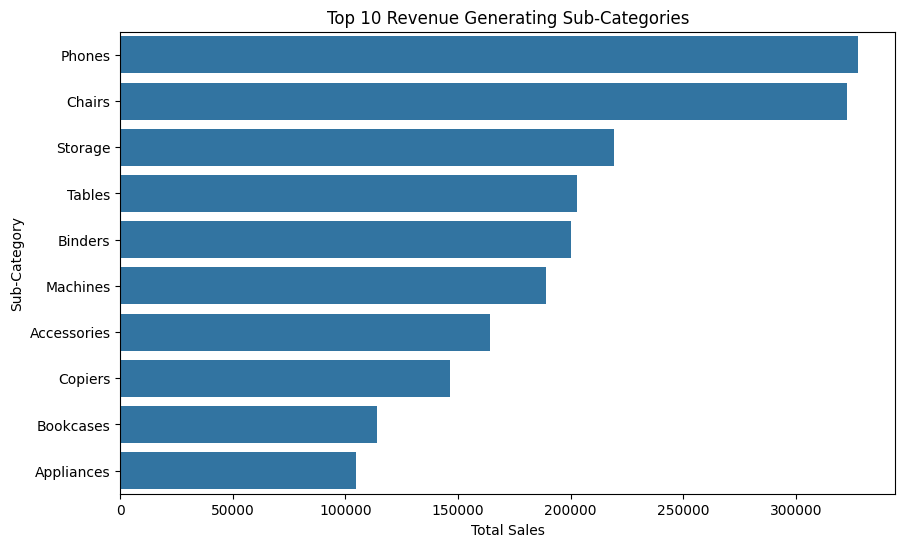

In [24]:
top10_subcat = subcategory_sales.head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top10_subcat.values, y=top10_subcat.index)

plt.title("Top 10 Revenue Generating Sub-Categories")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.show()

## Regional Sales Analysis

Understanding regional sales distribution helps identify the strongest
and weakest markets for the business.

This analysis helps answer key questions:

- Which regions generate the highest revenue?
- Which regions need improvement?
- Where should business expansion focus?

In [25]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

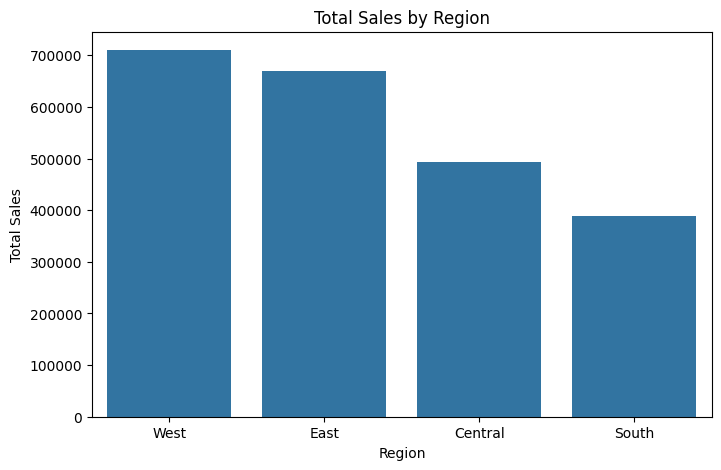

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(x=region_sales.index, y=region_sales.values)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

## City Level Sales Analysis

City level analysis helps identify specific locations that drive
a large portion of the business revenue.

Understanding top-performing cities helps businesses:

- optimize distribution networks
- target marketing campaigns
- prioritize inventory in high-demand areas

In [27]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)

city_sales.head(10)

City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64

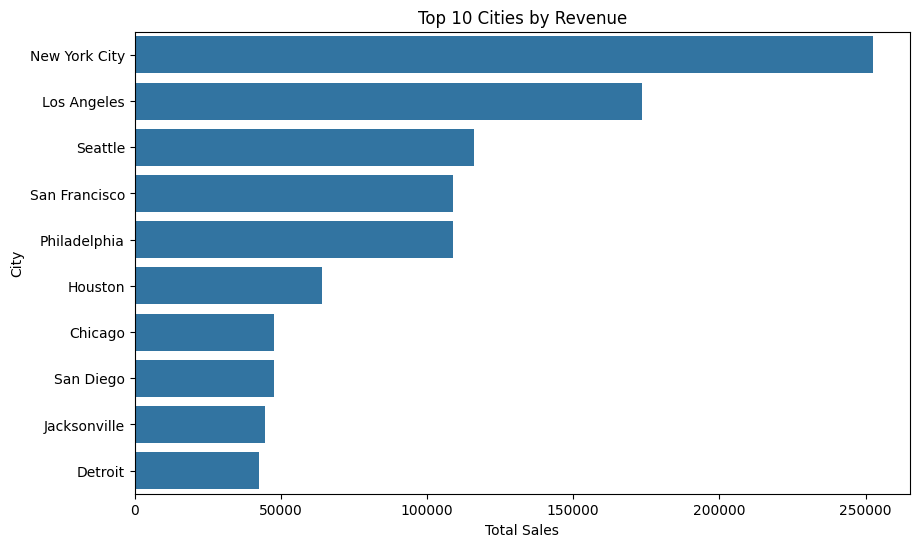

In [28]:
top10_cities = city_sales.head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top10_cities.values, y=top10_cities.index)

plt.title("Top 10 Cities by Revenue")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.show()

## Customer Revenue Analysis

Customer analysis helps identify the most valuable customers
who contribute significantly to business revenue.

Understanding customer purchasing patterns allows businesses to:

- identify VIP customers
- design loyalty programs
- prioritize high-value customers

In [29]:
customer_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

customer_sales.head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

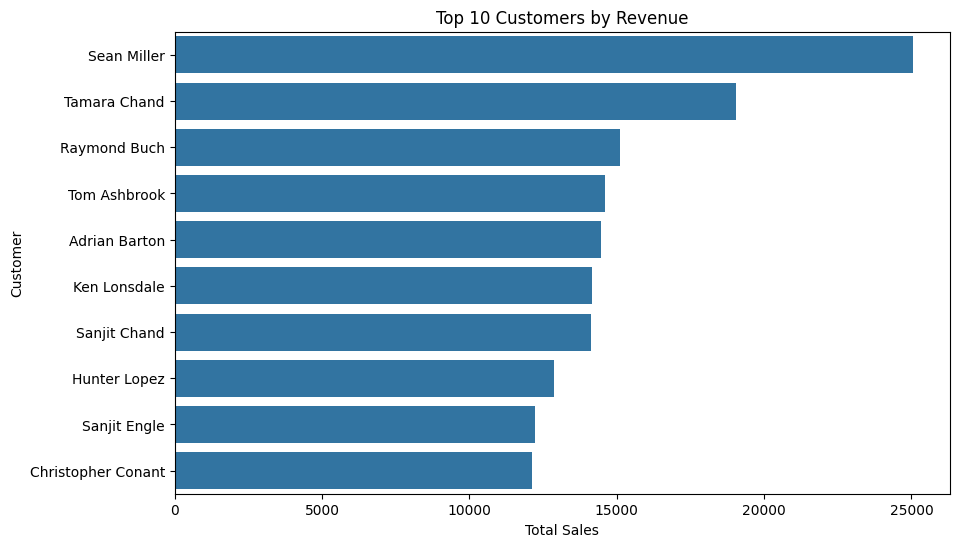

In [30]:
top10_customers = customer_sales.head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top10_customers.values, y=top10_customers.index)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Sales")
plt.ylabel("Customer")

plt.show()

## RFM Customer Segmentation

RFM analysis is a marketing technique used to evaluate customer behavior.

It segments customers based on three key metrics:

Recency → How recently a customer made a purchase  
Frequency → How often a customer makes purchases  
Monetary → How much money a customer spends

RFM segmentation helps businesses identify:

- loyal customers
- high-value customers
- customers at risk of churning
- new customers

This allows companies to design targeted marketing strategies.

In [31]:
# Define analysis date
analysis_date = df['Order Date'].max()

analysis_date

Timestamp('2018-12-30 00:00:00')

## Building the RFM Table

In this step we compute the three core metrics used in RFM analysis.

Recency → Days since the customer's last purchase  
Frequency → Total number of purchases made by the customer  
Monetary → Total revenue generated by the customer

In [32]:
rfm = df.groupby('Customer Name').agg({
    'Order Date': lambda x: (analysis_date - x.max()).days,
    'Order ID': 'count',
    'Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer Name,,,
Aaron Bergman,415,6,886.156
Aaron Hawkins,12,11,1744.700
Aaron Smayling,88,10,3050.692
Adam Bellavance,54,18,7755.620
Adam Hart,34,20,3250.337


## RFM Scoring

To segment customers effectively, we assign scores from 1 to 5 for each RFM metric.

- Recency Score: lower recency gets a higher score
- Frequency Score: higher frequency gets a higher score
- Monetary Score: higher spending gets a higher score

These scores help classify customers into meaningful business segments.

In [33]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer Name,,,,,,
Aaron Bergman,415,6,886.156,1,1,1
Aaron Hawkins,12,11,1744.700,5,3,3
Aaron Smayling,88,10,3050.692,3,2,4
Adam Bellavance,54,18,7755.620,3,5,5
Adam Hart,34,20,3250.337,4,5,4


## Creating the Combined RFM Score

After calculating the individual R, F, and M scores,
we combine them to form a single RFM score.

This score represents the overall customer value
based on purchasing behavior.

In [34]:
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer Name,,,,,,,
Aaron Bergman,415,6,886.156,1,1,1,111
Aaron Hawkins,12,11,1744.700,5,3,3,533
Aaron Smayling,88,10,3050.692,3,2,4,324
Adam Bellavance,54,18,7755.620,3,5,5,355
Adam Hart,34,20,3250.337,4,5,4,454


## Customer Segmentation

Using the RFM scores, customers can be grouped into meaningful segments
based on their purchasing behavior.

Common customer segments include:

Champions → Best customers who buy frequently and spend the most  
Loyal Customers → Frequent buyers with good spending habits  
Potential Loyalists → Recent customers with growth potential  
At Risk → Customers who haven't purchased recently  
Lost Customers → Customers who have not purchased for a long time

Segmenting customers helps businesses design targeted marketing strategies.

In [35]:
def segment_customer(row):
    
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    
    if r >= 4 and f >= 4:
        return "Champions"
    
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    
    elif r >= 4 and f <= 2:
        return "Potential Loyalists"
    
    elif r <= 2 and f >= 3:
        return "At Risk"
    
    else:
        return "Others"


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer Name,,,,,,,,
Aaron Bergman,415,6,886.156,1,1,1,111,Others
Aaron Hawkins,12,11,1744.700,5,3,3,533,Loyal Customers
Aaron Smayling,88,10,3050.692,3,2,4,324,Others
Adam Bellavance,54,18,7755.620,3,5,5,355,Loyal Customers
Adam Hart,34,20,3250.337,4,5,4,454,Champions


## Customer Segment Distribution

After segmenting customers using RFM analysis,
we examine how customers are distributed across different segments.

This helps understand the overall health of the customer base
and identify opportunities for targeted marketing strategies.

In [36]:
segment_counts = rfm['Segment'].value_counts()

segment_counts

Segment
Others                 225
Loyal Customers        167
Champions              159
At Risk                150
Potential Loyalists     92
Name: count, dtype: int64

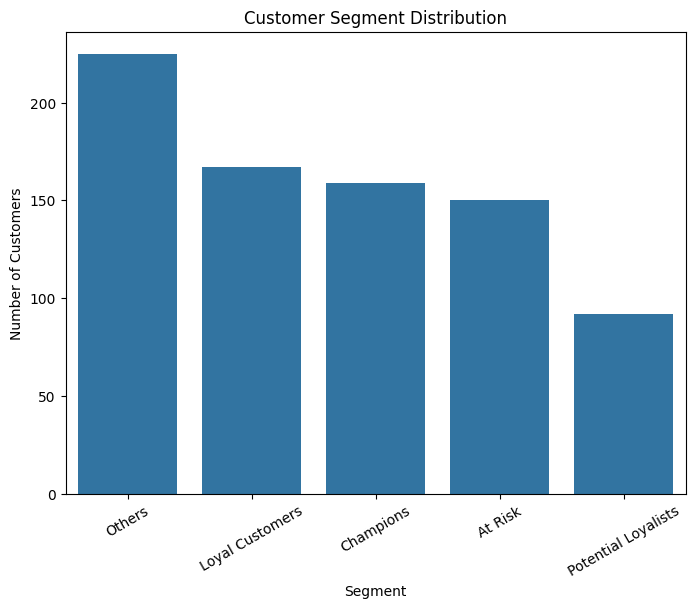

In [37]:
plt.figure(figsize=(8,6))

sns.barplot(x=segment_counts.index, y=segment_counts.values)

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

## Sales Trend Analysis

Time-based analysis helps understand how sales change over time.

This analysis helps identify:

- yearly growth trends
- seasonal sales patterns
- high demand periods

Understanding these patterns helps businesses plan inventory,
marketing campaigns, and sales strategies.

In [39]:
yearly_sales = df.groupby("Order Year")["Sales"].sum()

yearly_sales

Order Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

## Yearly Sales Growth Visualization

To better understand the growth pattern of the business,
we visualize total sales across different years.

This helps identify whether the business is expanding
or experiencing fluctuations in revenue.

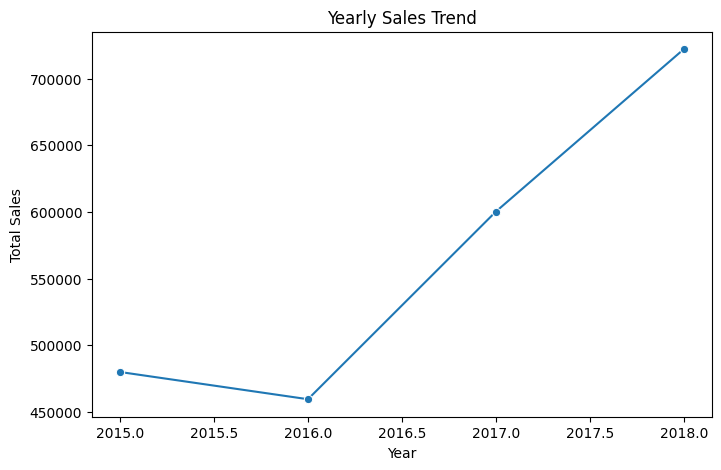

In [40]:
plt.figure(figsize=(8,5))

sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker='o')

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

## Monthly Sales Trend Analysis

Monthly analysis helps identify seasonal patterns in sales.

Businesses often experience demand fluctuations across different months.
Understanding these patterns helps optimize inventory management,
marketing campaigns, and supply chain planning.

In [41]:
monthly_sales = df.groupby("Order Month")["Sales"].sum()

monthly_sales

Order Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64

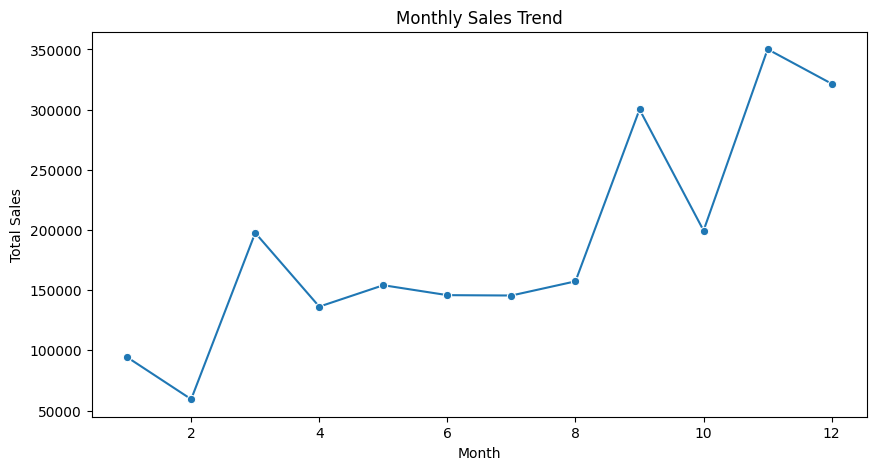

In [42]:
plt.figure(figsize=(10,5))

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

## Shipping Efficiency Analysis

Shipping efficiency is an important factor in customer satisfaction
and operational performance.

In this section we analyze the average shipping delay and evaluate
how different shipping modes perform in terms of delivery speed.

In [43]:
# Average shipping delay
avg_shipping_delay = df['Shipping Delay'].mean()

print("Average Shipping Delay (days):", round(avg_shipping_delay,2))

Average Shipping Delay (days): 3.96


## Shipping Mode Performance

Different shipping modes offer different delivery speeds.

In this section we analyze the average shipping delay for each
shipping mode to evaluate logistics performance.

In [44]:
shipping_mode_delay = df.groupby("Ship Mode")["Shipping Delay"].mean().sort_values()

shipping_mode_delay

Ship Mode
Same Day          0.044610
First Class       2.179214
Second Class      3.249211
Standard Class    5.008363
Name: Shipping Delay, dtype: float64

## Shipping Mode Delivery Speed

Visualizing the average delivery delay for each shipping mode
helps compare logistics performance.

This analysis identifies which shipping methods provide
the fastest delivery experience.

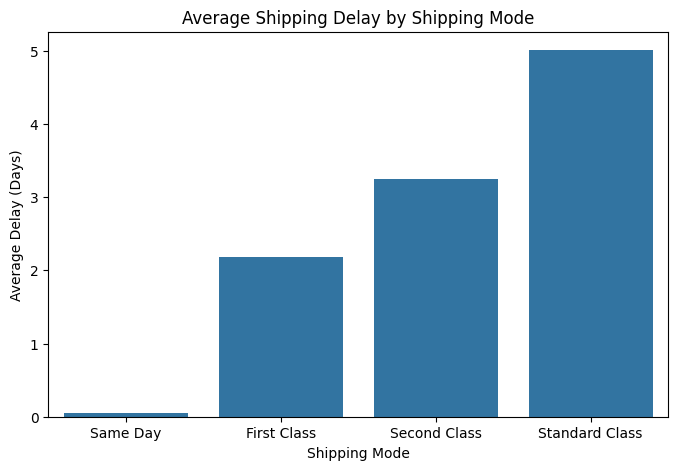

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(x=shipping_mode_delay.index, y=shipping_mode_delay.values)

plt.title("Average Shipping Delay by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delay (Days)")

plt.show()

## Time Series Preparation for Sales Forecasting

To forecast future sales trends, we first prepare a time series dataset.

This involves aggregating sales by time periods so that we can analyze
how sales evolve over time.

In [46]:
# Create monthly sales time series
monthly_ts = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum()

monthly_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

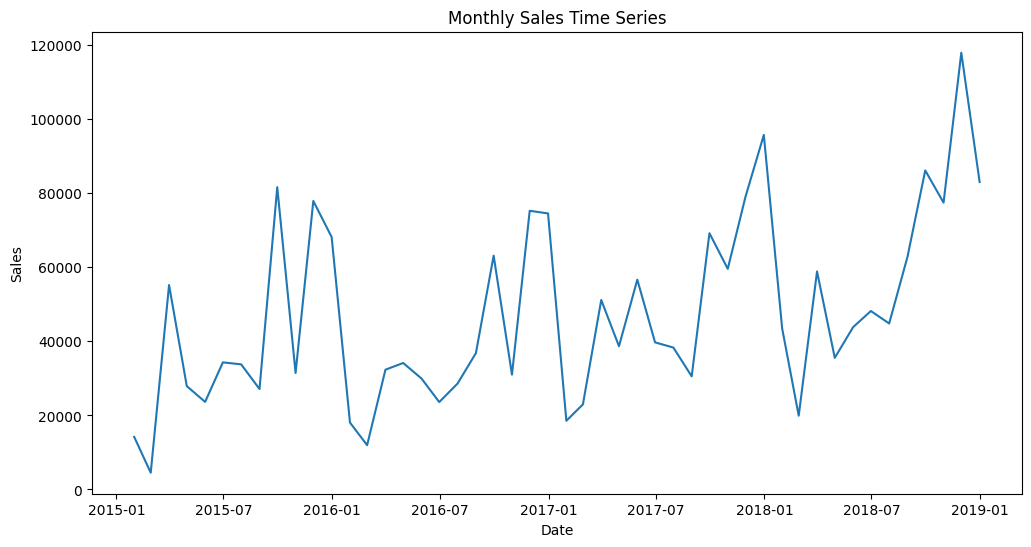

In [47]:
plt.figure(figsize=(12,6))

plt.plot(monthly_ts.index, monthly_ts.values)

plt.title("Monthly Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

## Stationarity Test

Before applying ARIMA forecasting, we need to determine whether
the time series is stationary.

Stationary data has constant statistical properties over time,
which is required for many time series models such as ARIMA.

We use the Augmented Dickey-Fuller (ADF) test to check stationarity.

In [48]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


## ARIMA Sales Forecasting Model

To forecast future sales trends, we apply the ARIMA model
(AutoRegressive Integrated Moving Average).

ARIMA is widely used in time series forecasting and helps predict
future values based on past observations.

In [49]:
from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA model
model = ARIMA(monthly_ts, order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -539.293
Date:                Fri, 13 Mar 2026   AIC                           1084.585
Time:                        17:23:53   BIC                           1090.136
Sample:                    01-31-2015   HQIC                          1086.674
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2546      0.265      0.961      0.337      -0.265       0.774
ma.L1         -0.8477      0.144     -5.898      0.000      -1.129      -0.566
sigma2      5.791e+08   8.52e-11   6.79e+18      0.0

## Sales Forecasting

Using the trained ARIMA model, we forecast the next 12 months
to estimate future sales trends.

Forecasting helps businesses plan inventory, marketing strategies,
and financial expectations.

In [50]:
forecast = model_fit.forecast(steps=12)

forecast

2019-01-31    74121.351923
2019-02-28    71852.991900
2019-03-31    71275.437079
2019-04-30    71128.383892
2019-05-31    71090.942182
2019-06-30    71081.409022
2019-07-31    71078.981752
2019-08-31    71078.363736
2019-09-30    71078.206381
2019-10-31    71078.166317
2019-11-30    71078.156116
2019-12-31    71078.153518
Freq: ME, Name: predicted_mean, dtype: float64

## Sales Forecast Visualization

To better understand the forecasting results, we visualize
historical sales alongside the predicted future sales.

This helps compare past trends with expected future performance.

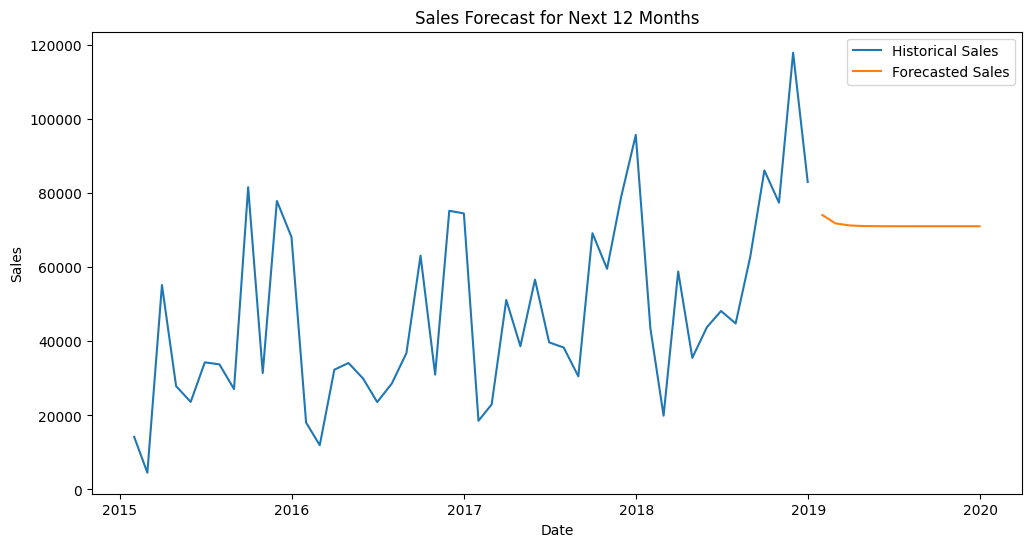

In [51]:
plt.figure(figsize=(12,6))

plt.plot(monthly_ts, label="Historical Sales")
plt.plot(forecast, label="Forecasted Sales")

plt.title("Sales Forecast for Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

## Market Basket Analysis

Market Basket Analysis identifies products that are frequently purchased together.

This technique is widely used in retail analytics and recommendation systems.

It helps businesses:

- recommend related products
- design product bundles
- optimize store layouts

In [52]:
basket = df.groupby(['Order ID','Sub-Category'])['Sales'].sum().unstack().fillna(0)

basket.head()

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Order ID,,,,,,,,,,,,,,,,,
CA-2015-100006,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,377.97,0.0,0.0,0.000
CA-2015-100090,0.0,0.0,0.0,196.704,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.00,0.0,0.0,502.488
CA-2015-100293,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,91.056,0.00,0.0,0.0,0.000
CA-2015-100328,0.0,0.0,0.0,3.928,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.00,0.0,0.0,0.000
CA-2015-100363,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,2.368,0.0,0.0,0.0,19.008,0.00,0.0,0.0,0.000


In [53]:
basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)

basket_sets.head()

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Order ID,,,,,,,,,,,,,,,,,
CA-2015-100006,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
CA-2015-100090,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
CA-2015-100293,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
CA-2015-100328,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
CA-2015-100363,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0


In [54]:
# !pip install mlxtend

## Frequent Itemset Mining using Apriori

The Apriori algorithm identifies frequently purchased product combinations
within transaction data.

This analysis helps businesses discover product associations that can be
used for recommendation systems, product bundling, and store layout optimization.

In [58]:
import warnings
warnings.filterwarnings("ignore")

In [59]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(basket_sets, min_support=0.02, use_colnames=True)

frequent_itemsets.sort_values(by="support", ascending=False).head(10)

,support,itemsets
3,0.262292,(Binders)
11,0.236286,(Paper)
8,0.173710,(Furnishings)
12,0.163145,(Phones)
13,0.155221,(Storage)
2,0.146282,(Art)
0,0.142625,(Accessories)
5,0.114994,(Chairs)
1,0.090207,(Appliances)
9,0.069078,(Labels)


In [60]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Binders),(Appliances),0.262292,0.090207,0.025599,0.097599,1.081939,1.0,0.001939,1.008191,0.102661,0.078310,0.008124,0.190691
1,(Appliances),(Binders),0.090207,0.262292,0.025599,0.283784,1.081939,1.0,0.001939,1.030008,0.083243,0.078310,0.029134,0.190691
5,(Phones),(Art),0.163145,0.146282,0.024787,0.151930,1.038612,1.0,0.000921,1.006660,0.044424,0.087081,0.006616,0.160687
4,(Art),(Phones),0.146282,0.163145,0.024787,0.169444,1.038612,1.0,0.000921,1.007585,0.043547,0.087081,0.007527,0.160687
7,(Phones),(Furnishings),0.163145,0.173710,0.029256,0.179328,1.032339,1.0,0.000916,1.006845,0.037433,0.095112,0.006799,0.173874
6,(Furnishings),(Phones),0.173710,0.163145,0.029256,0.168421,1.032339,1.0,0.000916,1.006345,0.037912,0.095112,0.006305,0.173874
3,(Appliances),(Paper),0.090207,0.236286,0.021942,0.243243,1.029444,1.0,0.000628,1.009193,0.031438,0.072048,0.009110,0.168053
2,(Paper),(Appliances),0.236286,0.090207,0.021942,0.092863,1.029444,1.0,0.000628,1.002928,0.037451,0.072048,0.002919,0.168053
8,(Furnishings),(Storage),0.173710,0.155221,0.027022,0.155556,1.002152,1.0,0.000058,1.000396,0.002599,0.089502,0.000395,0.164820
9,(Storage),(Furnishings),0.155221,0.173710,0.027022,0.174084,1.002152,1.0,0.000058,1.000453,0.002542,0.089502,0.000452,0.164820


## Interpreting Association Rules

To make the association rules easier to understand for business stakeholders,
we convert the rule metrics into simple natural language insights.

Each rule explains which products are commonly purchased together
and how strong the relationship is.

In [61]:
for index, row in rules.sort_values(by="lift", ascending=False).head(10).iterrows():
    
    antecedent = list(row['antecedents'])[0]
    consequent = list(row['consequents'])[0]
    
    support = round(row['support']*100,2)
    confidence = round(row['confidence']*100,2)
    lift = round(row['lift'],2)
    
    print(f"If a customer buys {antecedent}, they are {lift} times more likely to also buy {consequent}.")
    print(f"Approximately {confidence}% of customers who buy {antecedent} also buy {consequent}.")
    print(f"This combination appears in {support}% of all orders.")
    print("--------------------------------------------------")

If a customer buys Binders, they are 1.08 times more likely to also buy Appliances.
Approximately 9.76% of customers who buy Binders also buy Appliances.
This combination appears in 2.56% of all orders.
--------------------------------------------------
If a customer buys Appliances, they are 1.08 times more likely to also buy Binders.
Approximately 28.38% of customers who buy Appliances also buy Binders.
This combination appears in 2.56% of all orders.
--------------------------------------------------
If a customer buys Phones, they are 1.04 times more likely to also buy Art.
Approximately 15.19% of customers who buy Phones also buy Art.
This combination appears in 2.48% of all orders.
--------------------------------------------------
If a customer buys Art, they are 1.04 times more likely to also buy Phones.
Approximately 16.94% of customers who buy Art also buy Phones.
This combination appears in 2.48% of all orders.
--------------------------------------------------
If a customer

## Customer Lifetime Value (CLV) Analysis

Customer Lifetime Value estimates the total revenue a customer
generates for the business over time.

By identifying high-value customers, businesses can:

- prioritize customer retention strategies
- design targeted marketing campaigns
- maximize long-term revenue.

In [62]:
clv = df.groupby("Customer Name").agg({
    "Sales":"sum",
    "Order ID":"count"
})

clv.columns = ["Total_Revenue","Total_Orders"]

clv["Average_Order_Value"] = clv["Total_Revenue"] / clv["Total_Orders"]

clv.head()

,Total_Revenue,Total_Orders,Average_Order_Value
Customer Name,,,
Aaron Bergman,886.156,6,147.692667
Aaron Hawkins,1744.700,11,158.609091
Aaron Smayling,3050.692,10,305.069200
Adam Bellavance,7755.620,18,430.867778
Adam Hart,3250.337,20,162.516850


In [63]:
clv["CLV"] = clv["Average_Order_Value"] * clv["Total_Orders"]

clv.sort_values(by="CLV", ascending=False).head(10)

,Total_Revenue,Total_Orders,Average_Order_Value,CLV
Customer Name,,,,
Sean Miller,25043.050,15,1669.536667,25043.050
Tamara Chand,19052.218,12,1587.684833,19052.218
Raymond Buch,15117.339,18,839.852167,15117.339
Tom Ashbrook,14595.620,10,1459.562000,14595.620
Adrian Barton,14473.571,20,723.678550,14473.571
Ken Lonsdale,14175.229,29,488.801000,14175.229
Sanjit Chand,14142.334,22,642.833364,14142.334
Hunter Lopez,12873.298,11,1170.299818,12873.298
Sanjit Engle,12209.438,19,642.602000,12209.438


## Executive Business Summary

This project performs an end-to-end retail sales analytics study using
transactional sales data.

The objective is to uncover key business insights related to:

- sales performance
- customer behavior
- product demand
- geographic distribution
- future sales forecasting

The analysis includes customer segmentation, market basket analysis,
time series forecasting, and customer lifetime value estimation.

These insights can help businesses improve decision-making,
optimize marketing strategies, and increase revenue.

In [64]:
total_sales = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer Name"].nunique()
avg_order_value = df["Sales"].mean()

print("Total Sales:", round(total_sales,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(avg_order_value,2))

Total Sales: 2261536.78
Total Orders: 4922
Total Customers: 793
Average Order Value: 230.77


## Revenue Contribution by Customer Segment

Customer segmentation helps identify which groups of customers
generate the most revenue.

Understanding segment contribution allows businesses to focus
marketing and retention strategies on high-value customers.

In [65]:
segment_revenue = rfm.merge(df.groupby("Customer Name")["Sales"].sum(),
                            left_index=True,
                            right_index=True)

segment_revenue.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

Segment
Champions              668753.6117
Loyal Customers        577306.2121
At Risk                561784.3883
Others                 294903.5250
Potential Loyalists    158789.0456
Name: Sales, dtype: float64

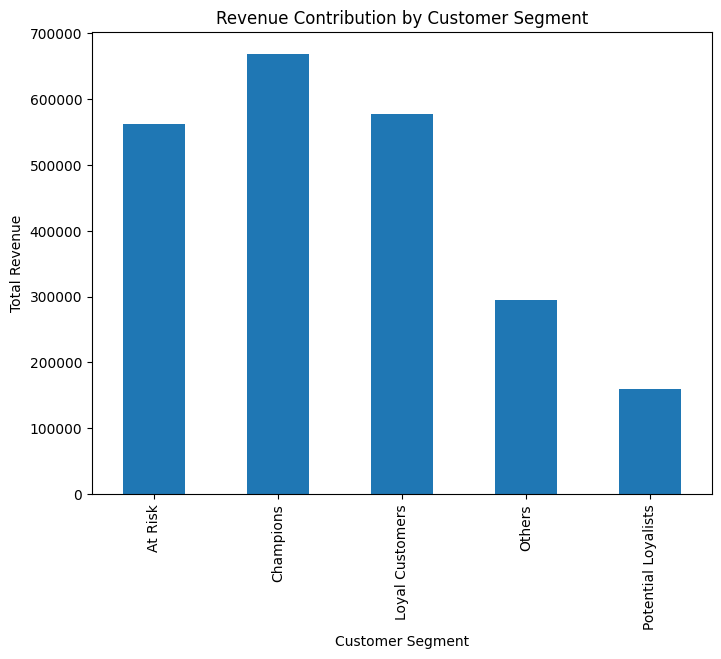

In [66]:
plt.figure(figsize=(8,6))

segment_revenue.groupby("Segment")["Sales"].sum().plot(kind="bar")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.show()

## Order Value Distribution

Analyzing the distribution of order values helps identify
high-value transactions and potential outliers.

Retail businesses often experience a long-tail distribution
where a small number of transactions generate a large portion
of total revenue.

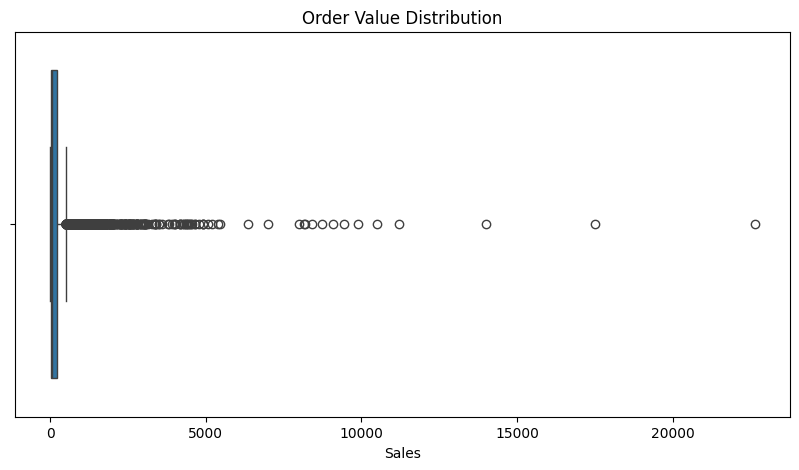

In [67]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Sales"])

plt.title("Order Value Distribution")

plt.show()

## Top Revenue Generating Customers

Identifying top customers helps businesses prioritize
customer relationship management and retention strategies.

High-value customers represent a critical portion
of overall revenue.

In [68]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

top_customers.head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

## Final Business Report — Retail Sales Analytics

### Project Overview

This project conducted an end-to-end analysis of retail sales transaction data to understand business performance, customer behavior, product demand, and future sales trends.

The analysis included:

* Exploratory Data Analysis (EDA)
* Customer Segmentation using RFM
* Market Basket Analysis
* Sales Forecasting using ARIMA
* Customer Lifetime Value (CLV)
* Business insights and strategic recommendations

The goal of this analysis is to provide actionable insights that help businesses improve decision-making, increase revenue, and optimize customer engagement strategies.

---

# Key Business Metrics

The overall business performance can be summarized with the following metrics:

* **Total Sales:** $2,261,536
* **Total Orders:** 4,922
* **Total Customers:** 793
* **Average Order Value:** $230.77

These values indicate that the business operates with a large number of moderate-value transactions while a smaller number of high-value purchases contribute significantly to total revenue.

---

# Sales Performance Insights

The analysis of sales across product categories revealed that:

* **Technology products generate the highest revenue**
* **Furniture contributes strong mid-range revenue**
* **Office Supplies appear frequently in transactions but generate lower individual order values**

This suggests that technology products act as **high-value drivers**, while office supplies represent **high-frequency purchases**.

---

# Customer Segmentation Insights

Using **RFM (Recency, Frequency, Monetary) segmentation**, customers were grouped into behavioral categories.

Revenue contribution by segment:

| Segment             | Revenue |
| ------------------- | ------- |
| Champions           | $668K   |
| Loyal Customers     | $577K   |
| At Risk             | $561K   |
| Others              | $294K   |
| Potential Loyalists | $158K   |

Key insights:

* **Champions and Loyal Customers generate the majority of revenue**
* **At Risk customers still contribute significant revenue**
* Losing these customers could negatively impact business performance

Recommended strategy:

* Implement **loyalty programs for Champions**
* Launch **re-engagement campaigns for At Risk customers**

---

# Geographic Sales Insights

Sales analysis across geographic regions shows that major metropolitan areas contribute significantly to total revenue.

Top revenue-generating cities include:

* New York City
* Los Angeles
* Seattle
* San Francisco
* Philadelphia

These markets represent strong demand centers and should be prioritized for marketing and inventory distribution.

---

# Customer Lifetime Value (CLV) Insights

Customer Lifetime Value analysis identifies the most valuable customers in the business.

Top customers include:

| Customer     | Revenue |
| ------------ | ------- |
| Sean Miller  | $25,043 |
| Tamara Chand | $19,052 |
| Raymond Buch | $15,117 |
| Tom Ashbrook | $14,595 |

These customers generate significantly more revenue than average customers and should be prioritized through:

* personalized promotions
* loyalty incentives
* premium support services

---

# Market Basket Analysis Insights

Market basket analysis was performed to identify products frequently purchased together.

Examples of product relationships:

* Binders → Appliances
* Phones → Furnishings
* Paper → Appliances

These relationships can support:

* recommendation systems
* cross-selling strategies
* product bundling promotions

Retailers can leverage these insights to increase average order value.

---

# Sales Forecasting Insights

Using an **ARIMA time series forecasting model**, future sales were predicted based on historical sales trends.

Forecast results suggest:

* Stable sales patterns across upcoming months
* Consistent demand levels throughout the forecast period

Forecasting helps businesses plan:

* inventory management
* marketing campaigns
* financial projections

---

# Order Value Insights

Order value analysis reveals a **long-tail distribution**, where most orders have moderate values but a small number of transactions represent very high-value purchases.

These large purchases significantly influence total revenue and likely represent corporate or bulk orders.

Businesses should focus on attracting and retaining these high-value buyers.

---

# Strategic Business Recommendations

Based on the analysis, the following strategies are recommended:

### 1. Focus on High-Value Customers

Develop loyalty programs and personalized marketing campaigns for Champions and Loyal Customers.

### 2. Improve Customer Retention

Target At Risk customers with re-engagement campaigns to prevent revenue loss.

### 3. Promote High-Margin Products

Technology products generate the highest revenue and should receive increased promotional focus.

### 4. Implement Product Bundling

Use product association insights to recommend complementary products and increase average order value.

### 5. Optimize Geographic Strategy

Focus marketing and distribution efforts on high-performing metropolitan markets.

### 6. Leverage Sales Forecasting

Use predictive insights to optimize inventory planning and demand management.

---

# Conclusion

This project demonstrates how data analytics can uncover valuable business insights from retail transaction data.

By combining exploratory analysis, customer segmentation, forecasting, and product association techniques, businesses can gain a deeper understanding of their operations and make data-driven strategic decisions.

These insights can support improved marketing strategies, better customer engagement, and sustained revenue growth.


In [69]:
df.to_csv("retail_sales_cleaned.csv", index=False)